# **Bank Telemarketing Dataset -- Macroeconomics EDA Approach**

In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
tele_df.shape

(41188, 21)

In [6]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [8]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


## **Formatting and Consistency check**

In [9]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis -- Social Economic Context and bank related attributes**

**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
    - **More on this:** Measure how much the employment changes over certian period of time(in this case, average over 3 months).

- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
    - **More on this:** Tracks how the average prices of a fixed "basket" of goods and services(like food, housing, clothing, healthcare) change over time(in this case, 1 month)

- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
    - **More on this:** how optimistic or pessimistic consumer feel about their financial situation. When confidence is high, people tend to spend more, boosting economic growth; when confidence is low, they cut back, which can slow the economy.

**Related to bank**

- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
    - **More on this:** It's the average interest rate at which european banks lend money/loan to each other for 3 months.

- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


**Target Variable**

In [10]:
tele_df['y'].value_counts(normalize=True).round(2) * 100

y
no     89.0
yes    11.0
Name: proportion, dtype: float64

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [11]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

## **Correlation Matrix**

In [12]:
numeric_cols = [col for col in tele_df.select_dtypes(['number']).columns]
cat_cols = [col for col in tele_df.select_dtypes(['object'])]

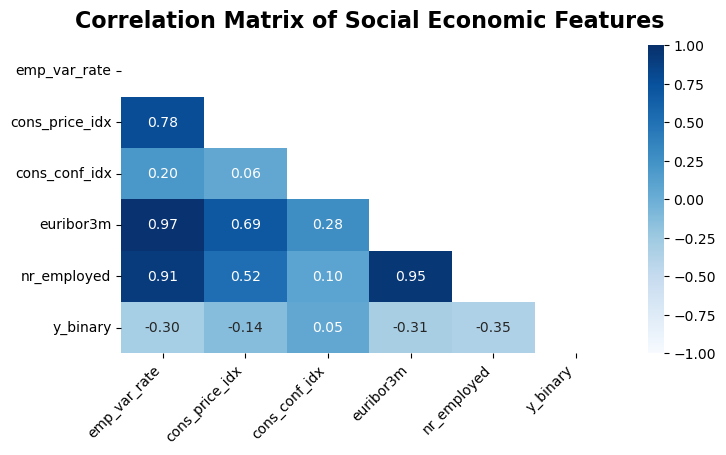

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
social_eco_df = tele_df[['emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary']]
corr_df = social_eco_df.select_dtypes(include='number').corr(method='pearson')
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_title('Correlation Matrix of Social Economic Features', fontsize=16, fontweight='bold', y=1.03)
plt.show()


**Strong Correlation :**

- emp_var_rate and euribor3m (0.97)
- nr_employed and euribor3m (0.95)
- nr_employed and emp_var_rate (0.91)
- cons_price_idx and emp_var_rate (0.78)

**Moderate Correlation :**

- euribor3m and cons_price_idx (0.69)
- nr_employed and cons_price_idx (0.52)

**Other are weak positive/negative correlation**

**Considering the given dataset is about customer subscribe for term deposit will depends on each customers monthly economic and social context and, undoubtedly,economic factors had an impact on customer's decision i.e., target y. Hence, decide to analyze deeper the month dimension.**

In [14]:
# Just a remainder: the observations are ordered by date (from May 2008 to November 2010.
months_arr = [
    [i, m] for i, m in enumerate(tele_df['month'])
    if i ==0 or m != tele_df['month'].iloc[i-1]
]
months_arr = np.array(months_arr)


We got:

**2008 : [0, 27690)**

**2009 : [27690, 39130)**

**2010 : [39130, 41188)**

In [15]:
# create year as column
tele_df['year'] = np.hstack(
    (np.array([2008] * (27690 - 0)),
    np.array([2009] * (39130 - 27690)),
    np.array([2010] * (41188 - 39130)))
)
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary', 'year'],
      dtype='object')

In [16]:
# Universal month order
order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
tele_df['month_order'] = pd.Categorical(tele_df['month'],categories=order, ordered=True)


In [17]:
list_cols = social_eco_df.columns.to_list()
list_cols.append('year')
social_eco_df = tele_df[list_cols]
social_eco_df.head()

,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,y_binary,year
0,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
1,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
2,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
3,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
4,1.1,93.994,-36.4,4.857,5191.0,no,0,2008


## **Dimension Analysis**

**Dimension : `emp_var_rate`**

emp_var_rate : employment variation rate -- quarterly inidcator (numeric)


Despite of **emp_var_rate** is a numeric feature, it has a small number of unique values:  

In [76]:
import sys
sys.path.append("..")
from src import my_file

In [80]:
unique_values, var_range, values_count = my_file.numeric_nature(social_eco_df, 'emp_var_rate')
print(f"Number of unique Values : {unique_values}\n")
print(f"Values vary from : {var_range}")
print(f"\n{values_count}")


Number of unique Values : 10

Values vary from : -3.4  to  1.4

emp_var_rate
 1.4    16234
-1.8     9184
 1.1     7763
-0.1     3683
-2.9     1663
-3.4     1071
-1.7      773
-1.1      635
-3.0      172
-0.2       10
Name: count, dtype: int64


**Seaonal Trend in `emp_var_rate`**

Just getting a general view how emp_var_rate looks throughout all 3 consecutive years.

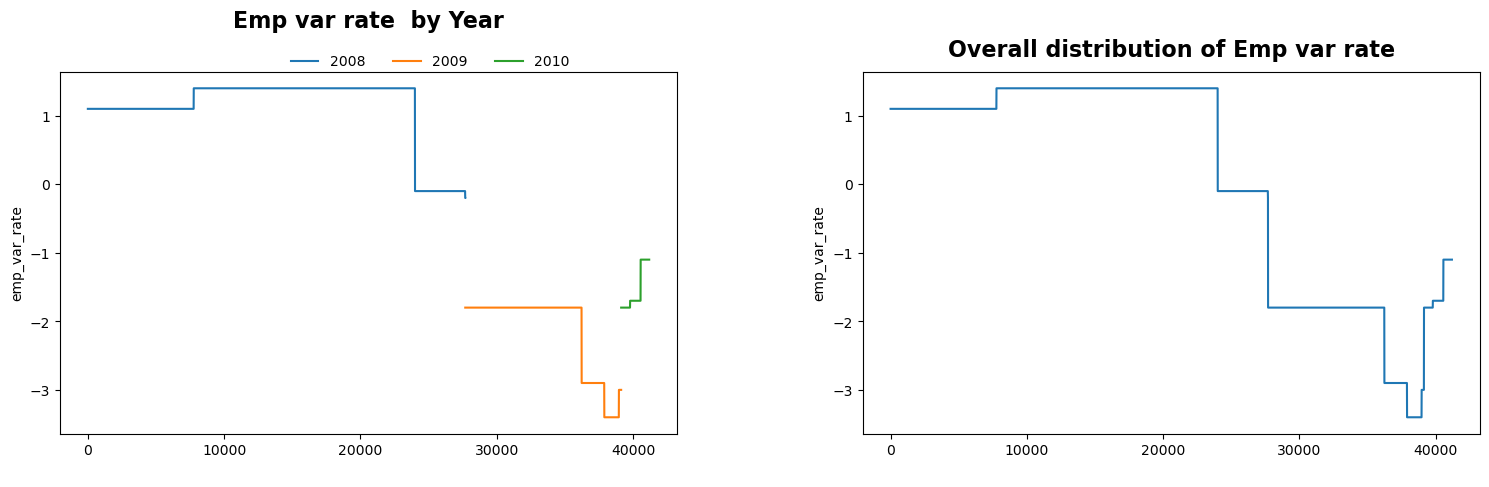

In [78]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))
my_file.numeric_var_by_year(social_eco_df, social_eco_df.index, 'emp_var_rate', 'year', fig=fig, ax=ax);


In [84]:
import importlib
importlib.reload(my_file)

<module 'src.my_file' from 'e:\\Bank-Telemarketing\\notebooks\\..\\src\\my_file.py'>

**Observations:**

- 2008 : the rate was pretty stable and a bit growing, except for the year ending(it dropped).
- 2009 : stable for inital period, then decreased, and at very end of 2009 it started to grow.
- 2010 :the rate was growing up.

Now, let's see how YES-proportion correlates with emp_Var_rate by month and year and throughout entire dataset.

In [22]:
def plot_overall_yes_proportion(df=None, month_var=None, year_var=None, feature_var=None, display_name=None, fig=None, ax=None):
    """Plot numeric variables median value for seasonal trend with overall and yes-proportion data"""  

    # Overall data
    total_df = pd.crosstab(
        df[month_var], df[year_var],
        df[feature_var], aggfunc='median'
    )
    
    # yes-proportion data
    new_df = df[df['y']=='yes']
    yes_df = pd.crosstab(
        new_df[month_var], new_df[year_var],
        new_df[feature_var], aggfunc='median'
    )
    # Visualization
    if fig is None or ax is None:
        fig, ax = plt.subplots(1,2, figsize=(15, 5))
    sns.heatmap(total_df, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax = ax[0])
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=25)
    ax[0].set_title(f"Overall median '{feature_var}' by {display_name.capitalize()} and {year_var.capitalize()}", fontsize=14,fontweight='bold', y=1.02)

    sns.heatmap(yes_df, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax = ax[1])
    ax[1].set_yticklabels(ax[0].get_yticklabels(), rotation=25)
    ax[1].set_title(f"YES-proportion median '{feature_var}' by {display_name.capitalize()} and {year_var.capitalize()}", fontsize=14, fontweight='bold', y=1.02)

    
    plt.show()

    return fig, ax

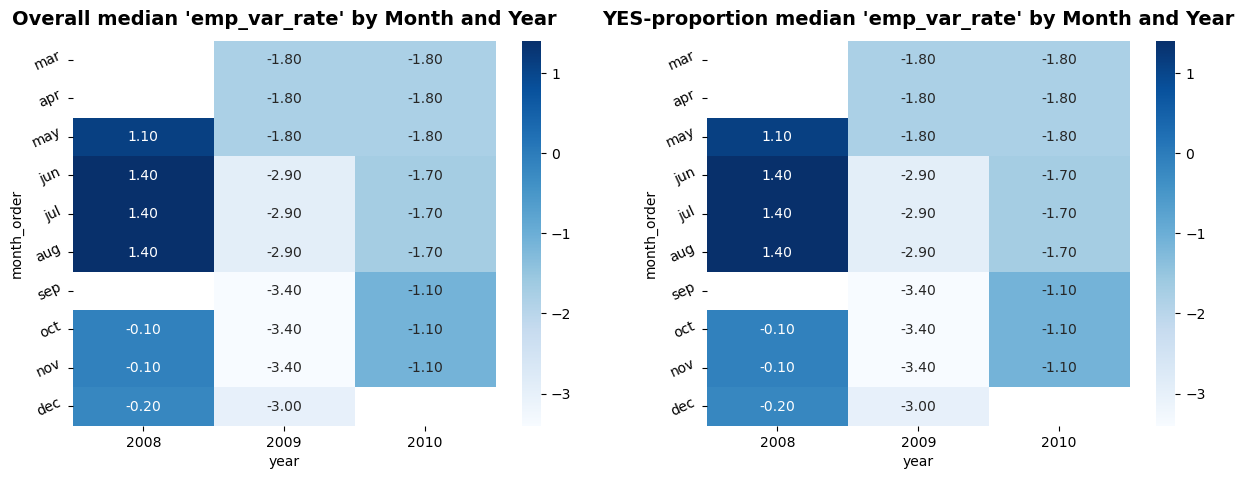

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
#plot_overall_yes_proportion(tele_df, 'month_order', 'year', 'emp_var_rate', 'month', fig, ax);
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'emp_var_rate', 'Month', fig, ax);


Median value of emp_var_rate by month and year is same for overall and yes-proportion data these variables are not good enough to differeniate emp_var_rate.

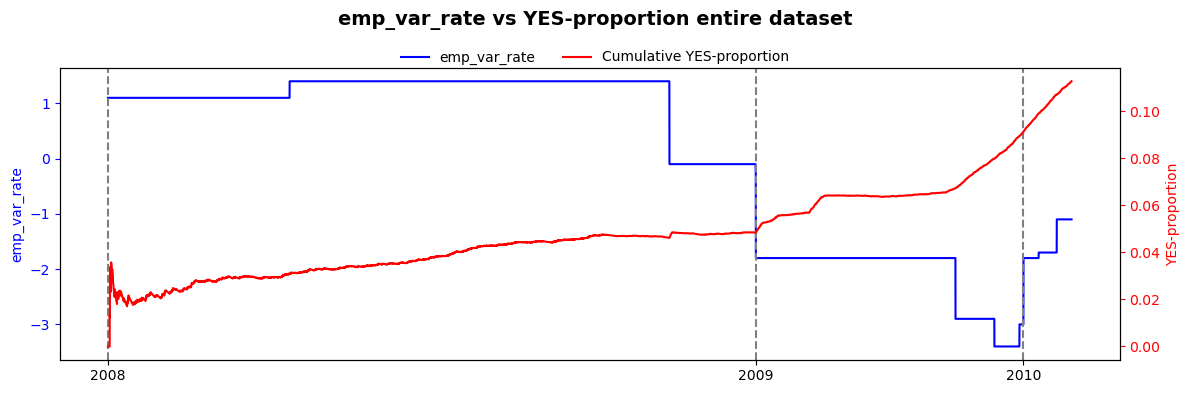

In [85]:
fig, ax = plt.subplots(figsize=(12, 4))
my_file.plot_num_var_yes_prop(tele_df, 'emp_var_rate', 'y_binary', fig, ax);

In [86]:
# Correlation with term deposit
feature_name = 'emp_var_rate'
print(f"Pearson Correlaton Coeff ({feature_name} vs y) : {tele_df[feature_name].corr(tele_df['y_binary']):.4f}")

Pearson Correlaton Coeff (emp_var_rate vs y) : -0.2983


As you see, it is a weak negative correlation. That means, the higher employment variation rate - the lower YES-proportion we got, and vice versa. And that seems quite reasonable: if the employment rate is highly various, people are not sure about their future and tend to make cautious decisions - so they give YES-answer less frequent. But we should be careful here and recall that correlation is not causation.

Check descriptive statistics distribution of Yes-No answers.

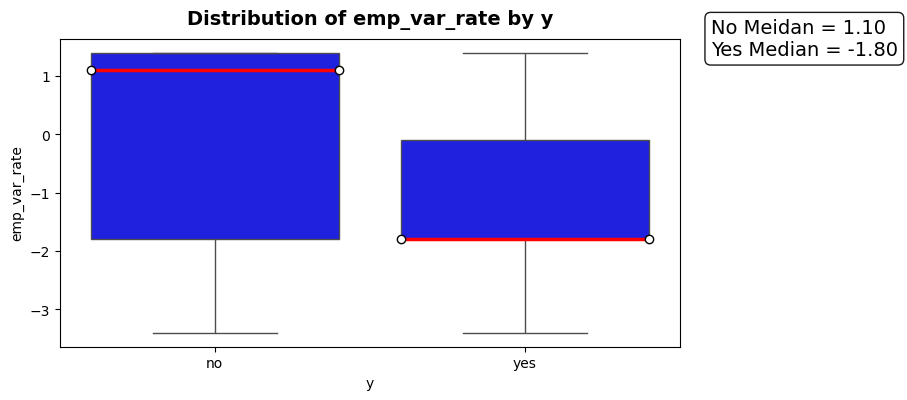

In [87]:
fig, ax = plt.subplots(figsize=(8, 4))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'emp_var_rate', fig, ax);

In [29]:
print("Various descriptive statistics of `emp_var_rate` by `y`\n")
print(tele_df.groupby(['y'])['emp_var_rate'].describe().round(2))

Various descriptive statistics of `emp_var_rate` by `y`

       count  mean   std  min  25%  50%  75%  max
y                                                
no   36548.0  0.25  1.48 -3.4 -1.8  1.1  1.4  1.4
yes   4640.0 -1.23  1.62 -3.4 -1.8 -1.8 -0.1  1.4


Clearly, there is huge difference between yes-no median and that's why this feature is useful for classification. Furthur, can be used of statistical analysis as well for more evidence.

In [89]:
data = my_file.var_by_year(tele_df, 'year', 'emp_var_rate')
data['std'] = np.sqrt(data['variation of `emp_var_rate`']).round(2)
data['var_over_year'] = data['variation of `emp_var_rate`'].pct_change().round(2)
data

,variation of `emp_var_rate`,Number of observatios(%),std,var_over_year
year,,,,
2008,0.24,67.2,0.49,NaN
2009,0.33,27.8,0.57,0.38
2010,0.09,5.0,0.30,-0.73


Both 2008 and 2009 have a higher employment variation rate and that's about 95% of all observations. As we all know, 2008 and 2009 were the years of the global financial crisis, so those 95% were obtained during a quite hard time for economy.

**Conclusion:**
- Values :
    - Number of unique values: 10
    - Vary from -3.4 to 1.4
- There is a weak negative correlation (-0.3) between emp_var_rate and YES-proportion, but not enough to predict term-deposit.
- There is a huge difference between medians of emp_var_rate for YES/NO-answers.
- 95% of answers were obtained during a quite hard time for economy and people.

---


**Dimension : `cons_price_idx`**

cons_price_idx : Consumer Price Index --- monthly indicator

Distribution of cons_price_idx:

In [90]:
unique_values, values_range, values_count = my_file.numeric_nature(social_eco_df, 'cons_price_idx')
print(f"Number of unique values : {unique_values}\n")
print(f"Values Range : {values_range}")


Number of unique values : 26

Values Range : 92.201  to  94.767


**Seasonal trend in `cons_price_idx`**

General view if 'cons_price_idx' throughout all three consecutive years.

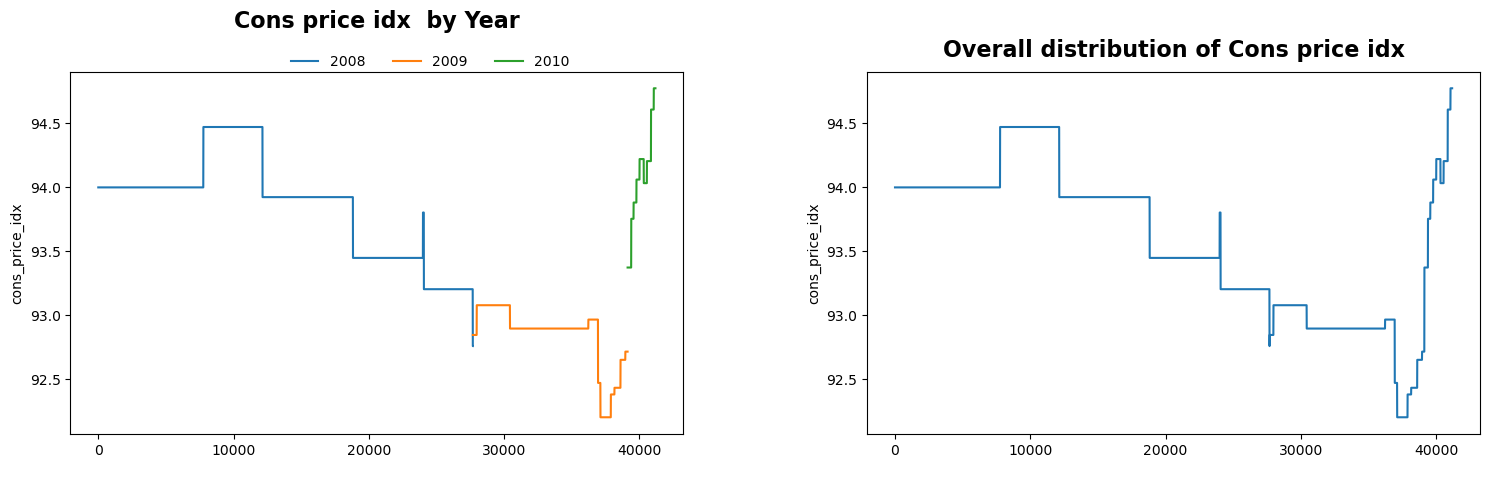

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.numeric_var_by_year(social_eco_df, social_eco_df.index, 'cons_price_idx', 'year', fig=fig, ax=ax);

**Observations:**
- 2008 and 2009 : Index was gradually decreasing with some short period of growth. And at the end of 2009 it start growing.
- 2010 : Prices dramatically went up.

Now, let's see how YES-proportion correlates with cons_price_idx by month and year and throughout entire dataset.

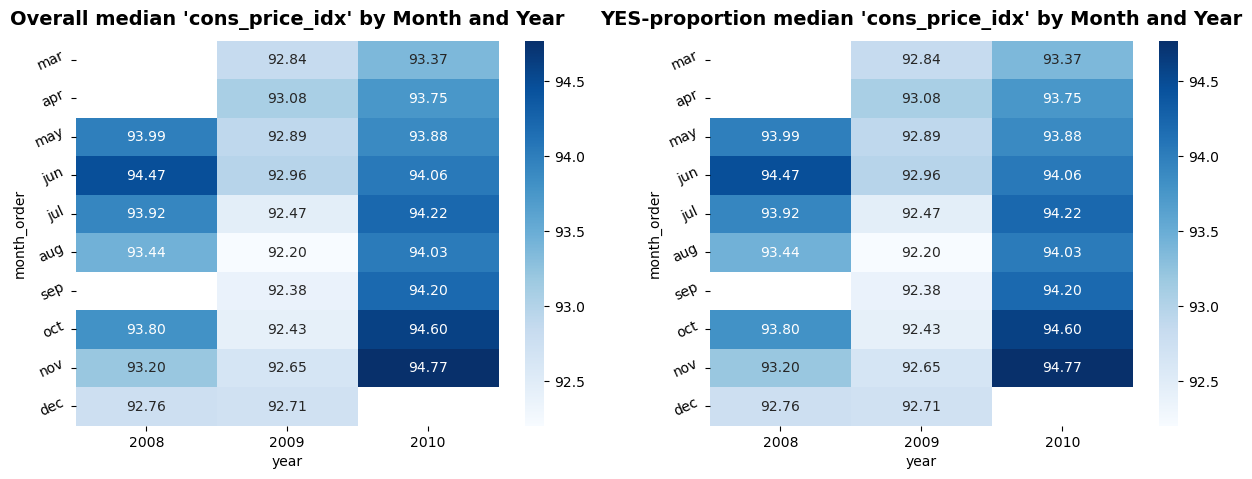

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'cons_price_idx', 'Month', fig=fig, ax=ax);

Median values of cons_price_idx by month and year for overall and yes-proportion data is same. These variables are good enough to differentiate cons_price_idx for yes/no data.

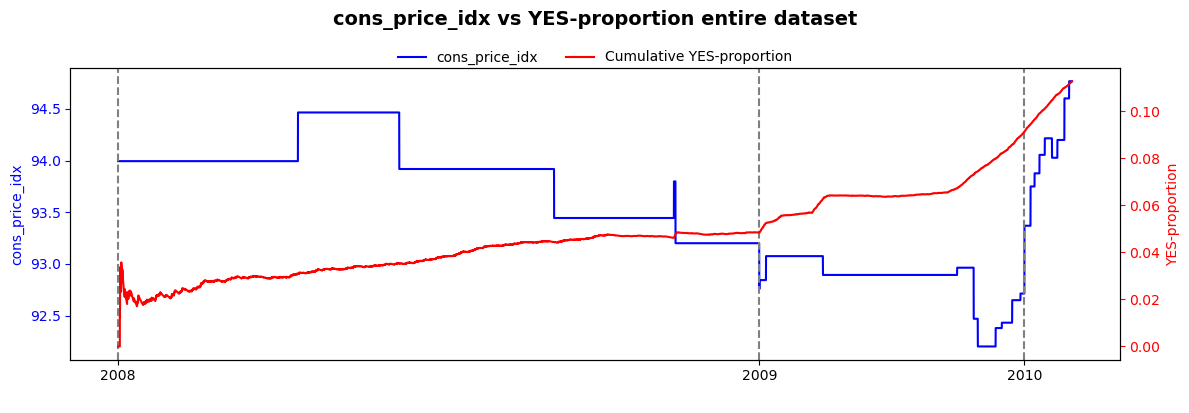

In [94]:
fig, ax = plt.subplots(figsize = (12, 4))
my_file.plot_num_var_yes_prop(tele_df, 'cons_price_idx', 'y_binary', fig=fig, ax=ax);

In [95]:
# Correlation with term deposit
feature_name = 'cons_price_idx'
print(f"Pearosn Correlation coeff (`{feature_name}` vs `y`) : {corr_df.loc[feature_name, 'y_binary']:.2f}")

Pearosn Correlation coeff (`cons_price_idx` vs `y`) : -0.14


**Interpretation :**
High `consumer price index (cons_price_idx)` --> consumers are less likely to subscribe(weak negative correlation).

Check descriptive statistics distribution of Yes-No answers.

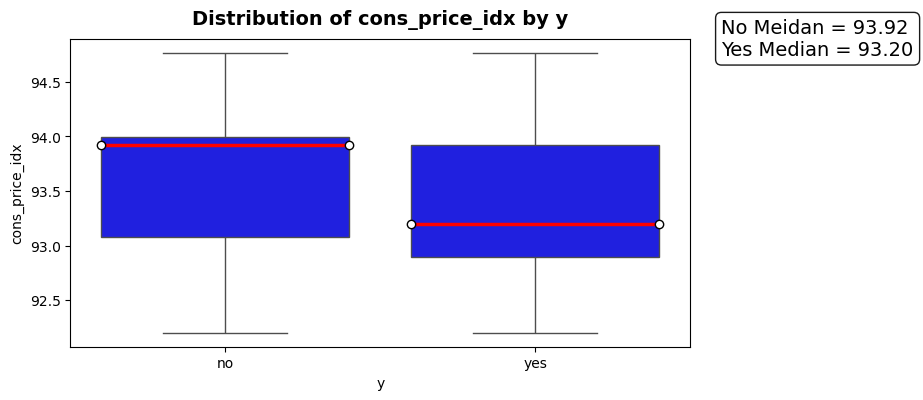

In [97]:
fig, ax = plt.subplots(figsize=(8, 4))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'cons_price_idx', fig=fig, ax=ax);

In [98]:
print("Various descriptive statistics of `cons_price_idx` by `y`\n")
print(tele_df.groupby(['y'])['cons_price_idx'].describe().round(2))

Various descriptive statistics of `cons_price_idx` by `y`

       count   mean   std   min    25%    50%    75%    max
y                                                          
no   36548.0  93.60  0.56  92.2  93.08  93.92  93.99  94.77
yes   4640.0  93.35  0.68  92.2  92.89  93.20  93.92  94.77


Clearly, there is no difference between yes-no median and that's why this feature is not useful for classification. Furthur, can be used of statistical analysis as well for more evidence.

In [102]:
# Compute variance in cons_price_idx by year
data = my_file.var_by_year(tele_df, 'year', 'cons_price_idx')
data['std'] = np.sqrt(data['variation of `cons_price_idx`']).round(2)
data['var_over_year'] = data['variation of `cons_price_idx`'].pct_change().round(4)
data

,variation of `cons_price_idx`,Number of observatios(%),std,var_over_year
year,,,,
2008,0.15,67.2,0.39,NaN
2009,0.06,27.8,0.24,-0.6000
2010,0.14,5.0,0.37,1.3333


- 2008 and 2010 were more stormy than 2009.
- CPI values were stable in 2009 which is good.
- CPI values were instable in 2008 and 2010 which indicate values fluctuate more within year.

In [103]:
print(f'Pearson corr. coef. (`{feature_name}` vs `emp_var_rate`): '
      f'{corr_df.loc[feature_name, 'emp_var_rate']:.2f}')

Pearson corr. coef. (`cons_price_idx` vs `emp_var_rate`): 0.78


Despite of strong correlation between cons_price_idx and emp_var_rate, 2009 was better than 2010 in terms of consumer prices.

**Conclusion:**
- Values :
    - Number of unique values : 26
    - Vary from -92.2 to 94.7
- There is a weak negative correlation (-0.14) between cons_price_idx and YES-proportion, but not enough to predict term-deposit.
- There is a huge difference between medians of cons_price_idx for YES/NO-answers.

---



**Dimension : `cons_conf_idx`**

cons_conf_idx : Consumer Confidence Index --- monthly indicator

Distribution of cons_conf_idx

In [104]:
unique_values, values_range, values_count = my_file.numeric_nature(social_eco_df, 'cons_conf_idx')
print(f"Number of unique values : {unique_values}\n")
print(f"Values range : {values_range}")

Number of unique values : 26

Values range : -50.8  to  -26.9


**Seasonal trend in** `cons_conf_idx`

General view of `cons_conf_idx` throughout all three consecutive years.

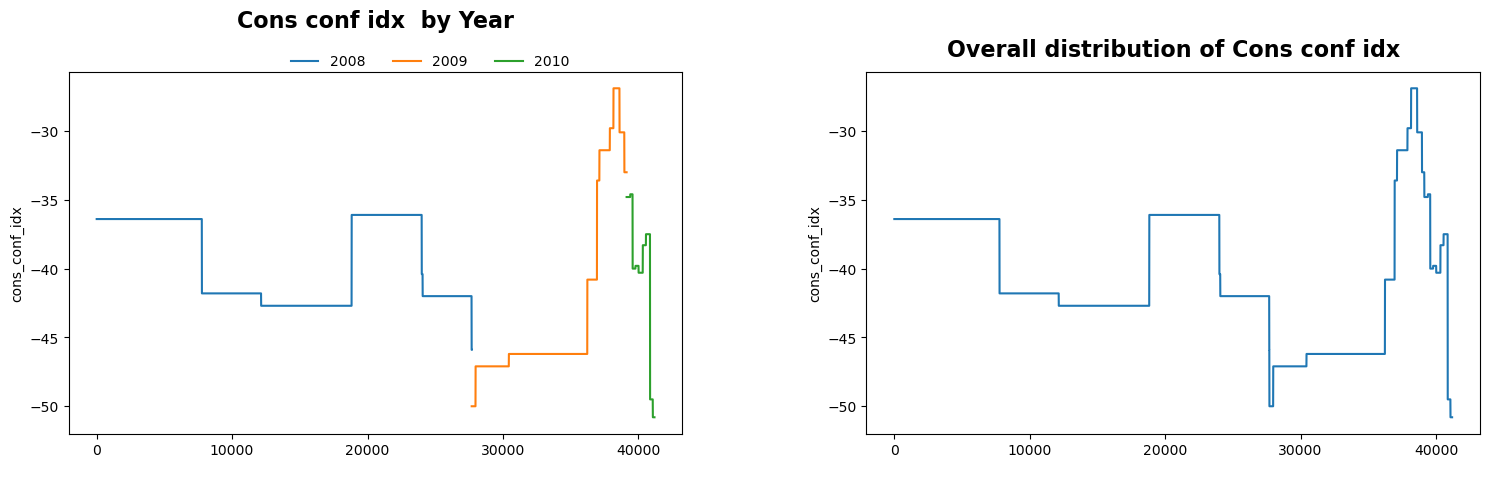

In [105]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.numeric_var_by_year(social_eco_df, social_eco_df.index, 'cons_conf_idx', 'year', fig=fig, ax=ax);

**Observations:**

- 2008: a consumer confidence varied a lot and was decreasing at the end of the year.
- 2009: an index was increasing and became pretty high before the drop at the end.
- 2010: a consumer confidence went down fast and that fully correlate with a consumer price index for that time.


Now, let's see how YES-proportion correlates with cons_conf_idx by month and year and throughout entire dataset.

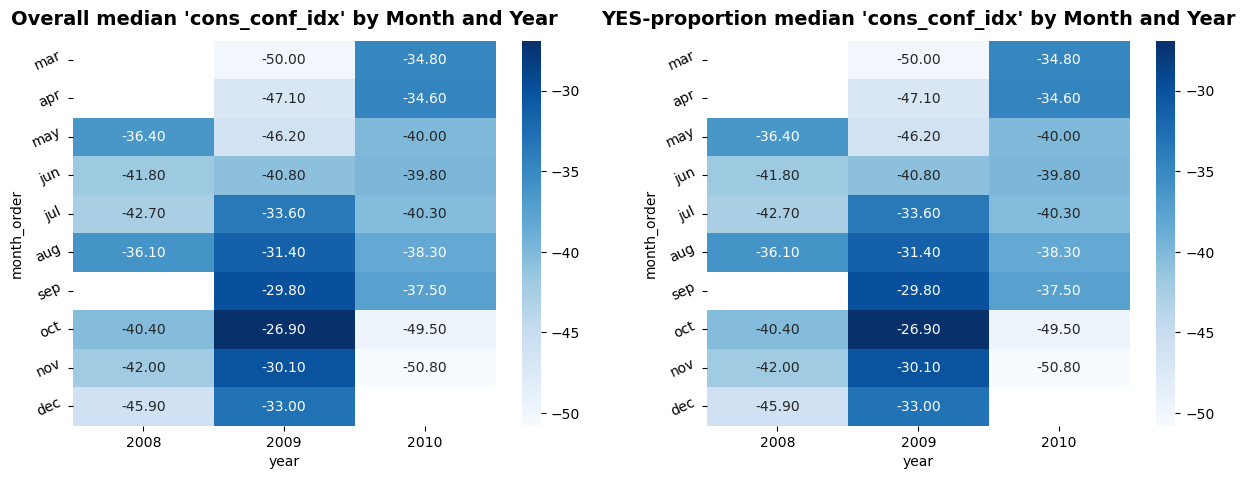

In [106]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'cons_conf_idx', 'Month', fig=fig, ax=ax);

Median values of cons_conf_idx by month and year for overall and yes-proportion data is same. These variables are good enough to differentiate cons_conf_idx for yes/no data.

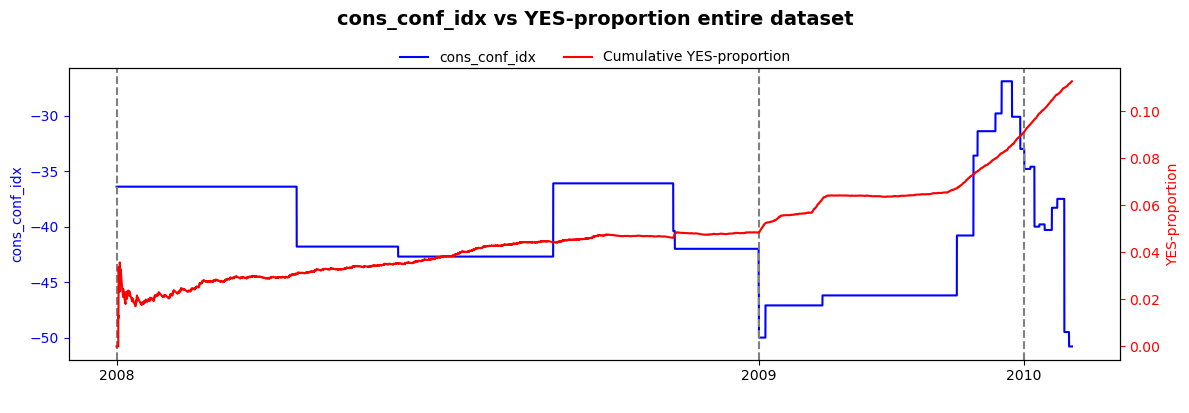

In [107]:
fig, ax = plt.subplots(figsize = (12, 4))
my_file.plot_num_var_yes_prop(tele_df, 'cons_conf_idx', 'y_binary', fig=fig, ax=ax);


In [108]:
# Correlation with term deposit
feature_name = 'cons_conf_idx'
print(f"Pearosn Correlation coeff (`{feature_name}` vs `y`) : {corr_df.loc[feature_name, 'y_binary']:.2f}")


Pearosn Correlation coeff (`cons_conf_idx` vs `y`) : 0.05


There is no significant correlation between cons.conf.idx and y. consumer confidence has almost no impact on whether clients subscribe to a term deposit

Check descriptive statistics distribution of Yes-No answers.

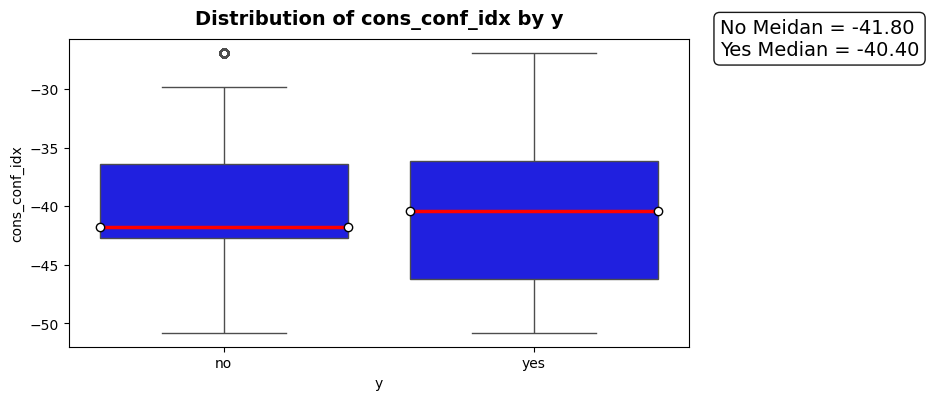

In [109]:
fig, ax = plt.subplots(figsize=(8, 4))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'cons_conf_idx', fig=fig, ax=ax);


Here we see that the medians are nearly equal.

In [110]:
print("Various descriptive statistics of `cons_conf_idx` by `y`\n")
print(tele_df.groupby(['y'])['cons_conf_idx'].describe().round(2))

Various descriptive statistics of `cons_conf_idx` by `y`

       count   mean   std   min   25%   50%   75%   max
y                                                      
no   36548.0 -40.59  4.39 -50.8 -42.7 -41.8 -36.4 -26.9
yes   4640.0 -39.79  6.14 -50.8 -46.2 -40.4 -36.1 -26.9


The most values are nearly equal in descriptive statistics and may required other features to classify term depost.

In [112]:
# Compute variance in cons_conf_idx by year
data = my_file.var_by_year(tele_df, 'year', 'cons_conf_idx')
data['std'] = np.sqrt(data['variation of `cons_conf_idx`']).round(2)
data['var_over_year'] = data['variation of `cons_conf_idx`'].pct_change().round(4)
data

,variation of `cons_conf_idx`,Number of observatios(%),std,var_over_year
year,,,,
2008,8.99,67.2,3.00,NaN
2009,41.62,27.8,6.45,3.6296
2010,23.41,5.0,4.84,-0.4375


In 2009-10 an indicator varied much more than in 2008.

In [113]:
print(f'Pearson corr. coef. (`{feature_name}` vs `emp_var_rate`): '
      f'{corr_df.loc[feature_name, 'emp_var_rate']:.2f}')

print(f'Pearson corr. coef. (`{feature_name}` vs `cons_price_idx`): '
      f'{corr_df.loc[feature_name, 'cons_price_idx']:.2f}')

Pearson corr. coef. (`cons_conf_idx` vs `emp_var_rate`): 0.20
Pearson corr. coef. (`cons_conf_idx` vs `cons_price_idx`): 0.06


**Conclusion :**

- Values:
    - Number of unique values: 26
    - Vary from -50.8 to -26.9
- There is no noticeable correlation between consumer confidence index and people's answers.
- Median values of cons.conf.idx for YES/NO-answers are nearly equal.

---

**Dimension : `euribor3m`**

euribor3m : Euribor 3-month rate --- daily indicator(numeric)

Distribution of `euribor3m`

In [114]:
unique_values, values_range, values_count = my_file.numeric_nature(social_eco_df, 'euribor3m')
print(f"Number of unique values : {unique_values}\n")
print(f"Values range : {values_range}")

Number of unique values : 316

Values range : 0.634  to  5.045


**Seasonal trend in** `euribo3m`

General view of `euribo3m` throughout all three consecutive years.

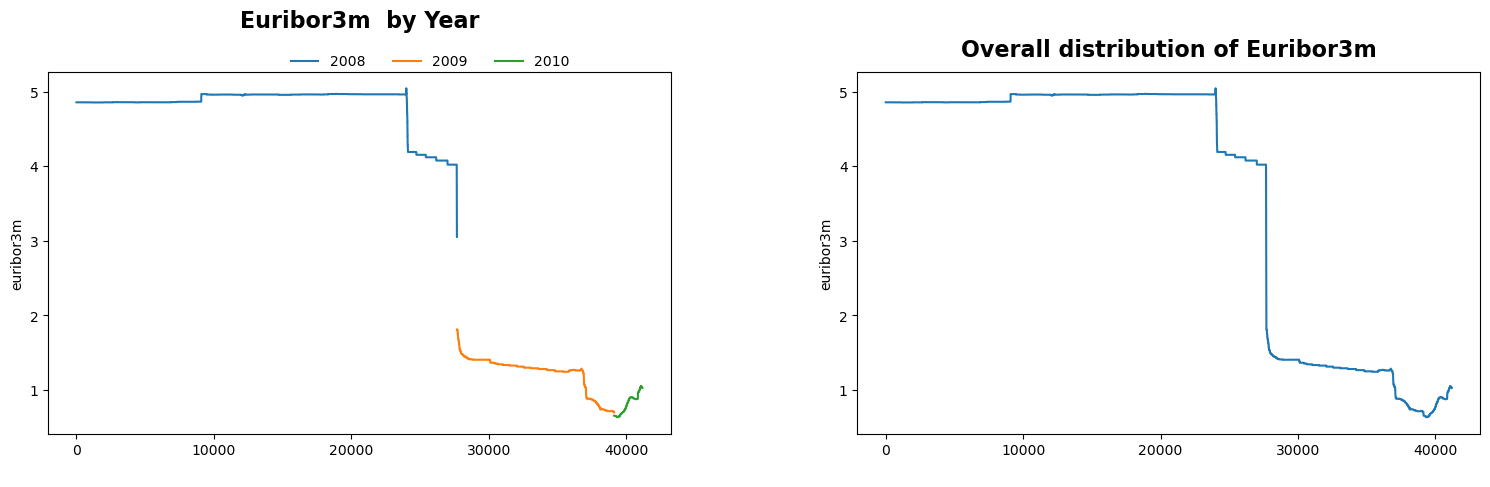

In [115]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.numeric_var_by_year(social_eco_df, social_eco_df.index, 'euribor3m', 'year', fig=fig, ax=ax);

**Observation :**

- 2008 : average interest rate was stable in initial months and dropped at the end.
- 2009 : euribor3m continued to gradually decreasing , but much slower than in the last months of 2008, there was another drop at the end of the year. 
- 20010 : It's start growing.

Now, let's see how YES-proportion correlates with euribor3m by month and year and throughout entire dataset.

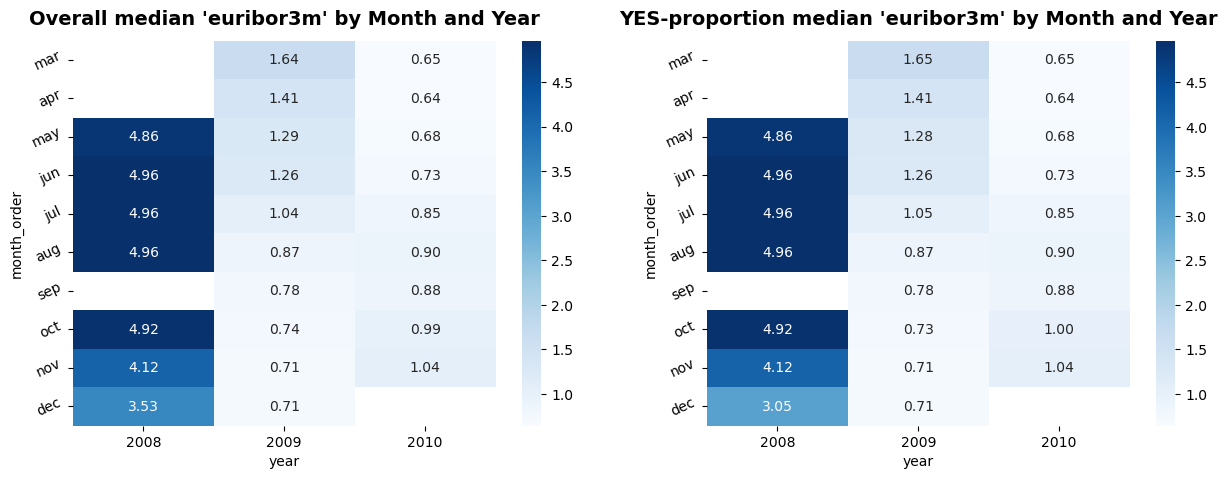

In [116]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'euribor3m', 'Month', fig=fig, ax=ax);

Median values of euribor3m by month and year for overall and yes-proportion data is same. These variables are good enough to differentiate euribor3m values for yes/no data.

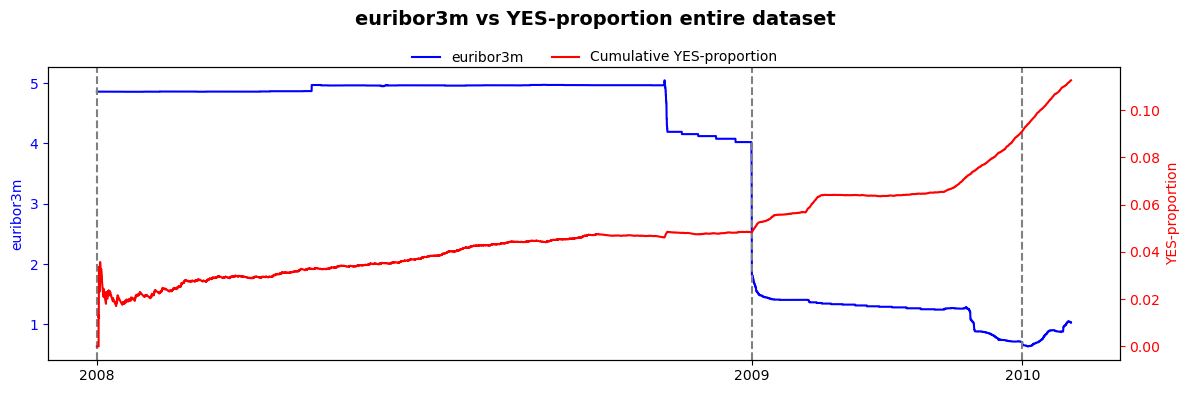

In [117]:
fig, ax = plt.subplots(figsize=(12, 4))
my_file.plot_num_var_yes_prop(tele_df, 'euribor3m', 'y_binary', fig=fig, ax=ax);

In [118]:
# Correlation with term deposit
feature_name = 'euribor3m'
print(f"Pearosn Correlation coeff (`{feature_name}` vs `y`) : {corr_df.loc[feature_name, 'y_binary']:.2f}")

Pearosn Correlation coeff (`euribor3m` vs `y`) : -0.31


There is a weak negative correlation between euribor3m and y. It indicate High euribor3m --> consumers are less likely to subscribe(weak negative correlation).

Check descriptive statistics distribution of Yes-No answers.

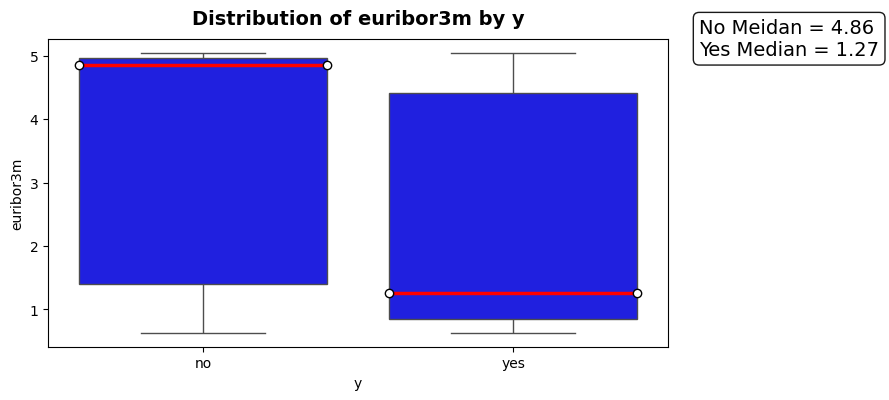

In [119]:
fig, ax = plt.subplots(figsize=(8, 4))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'euribor3m', fig=fig, ax=ax);


In [120]:
print("Various descriptive statistics of `euribor3m` by `y`\n")
print(tele_df.groupby(['y'])['euribor3m'].describe().round(2))

Various descriptive statistics of `euribor3m` by `y`

       count  mean   std   min   25%   50%   75%   max
y                                                     
no   36548.0  3.81  1.64  0.63  1.40  4.86  4.96  5.04
yes   4640.0  2.12  1.74  0.63  0.85  1.27  4.41  5.04


Clearly, there is huge difference between yes-no median and that's why this feature is useful for classification. Furthur, can be used of statistical analysis as well for more evidence.

In [122]:
# Compute variance in cons_price_idx by year
data = my_file.var_by_year(tele_df, 'year', 'euribor3m')
data['std'] = np.sqrt(data['variation of `euribor3m`']).round(2)
data['var_over_year'] = data['variation of `euribor3m`'].pct_change().round(2)
data

,variation of `euribor3m`,Number of observatios(%),std,var_over_year
year,,,,
2008,0.08,67.2,0.28,NaN
2009,0.05,27.8,0.22,-0.38
2010,0.02,5.0,0.14,-0.60


In 2008-09 an indicator varied much more than in 2010.

- 2008-09 : Customers may react differently depending on when they were contacted (early vs. late in the year). Campaign outcomes vary more. Deposit subscription behavior (y) is more volatile and strongly influenced by the timing of calls.

- 2010 : Customer behavior is more consistent, so the predictive power of euribor3m is weaker/less inforamtive and other feature matters more.

In [123]:
print(f'Pearson corr. coef. (`{feature_name}` vs `emp_var_rate`): '
      f'{corr_df.loc[feature_name, 'emp_var_rate']:.2f}')

print(f'Pearson corr. coef. (`{feature_name}` vs `cons_price_idx`): '
      f'{corr_df.loc[feature_name, 'cons_price_idx']:.2f}')

print(f'Pearson corr. coef. (`{feature_name}` vs `cons_conf_idx`): '
      f'{corr_df.loc[feature_name, 'cons_conf_idx']:.2f}')

Pearson corr. coef. (`euribor3m` vs `emp_var_rate`): 0.97
Pearson corr. coef. (`euribor3m` vs `cons_price_idx`): 0.69
Pearson corr. coef. (`euribor3m` vs `cons_conf_idx`): 0.28


- Despite being highly, moderatly, weakly correlated with `emp_var_rate`, `cons_price_idx`, `cons_conf_idx` resp. `euribor3m` more stable than former features in corresponding years.

**Conclusion :**

- Values:
    - Number of unique values: 316
    - Vary from 0.634 to 5.045
- There is a small negative correlation (-0.31) between euribor3m and y.
- There is a huge difference between medians of euribor3m for YES/NO-answers.

---

**Dimension : `nr_employed`**

nr_employed: Number of employees - quarterly indicator(numeric)

Distribution of `nr_employed`

In [124]:
unique_values, values_range, values_count = my_file.numeric_nature(social_eco_df, 'nr_employed')
print(f"Number of unique values : {unique_values}\n")
print(f"Values range : {values_range}")
print(f"\n{values_count}")

Number of unique values : 11

Values range : 4963.6  to  5228.1

nr_employed
5228.1    16234
5099.1     8534
5191.0     7763
5195.8     3683
5076.2     1663
5017.5     1071
4991.6      773
5008.7      650
4963.6      635
5023.5      172
5176.3       10
Name: count, dtype: int64


**Seaosnal trend in** `nr_employed`

General view of 'nr_employed' throughout all three consecutive years and overall.

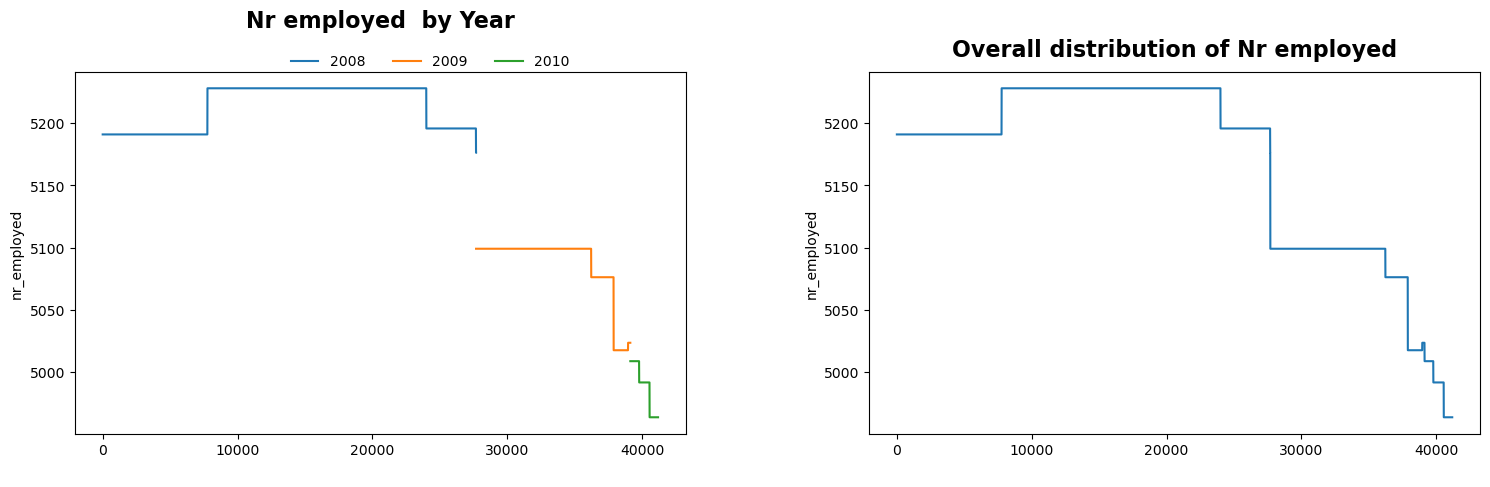

In [125]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.numeric_var_by_year(tele_df, tele_df.index, 'nr_employed', 'year', fig=fig, ax=ax);

**Observations :**

- 2008: during that year nr_employed was growing but dropped at the end.
- 2009: it was stable and there was another drop at the last months
- 2010: nr_employed continued to fall down.

Now, let's see how YES-proportion correlates with nr_employed by month and year and throughout entire dataset.

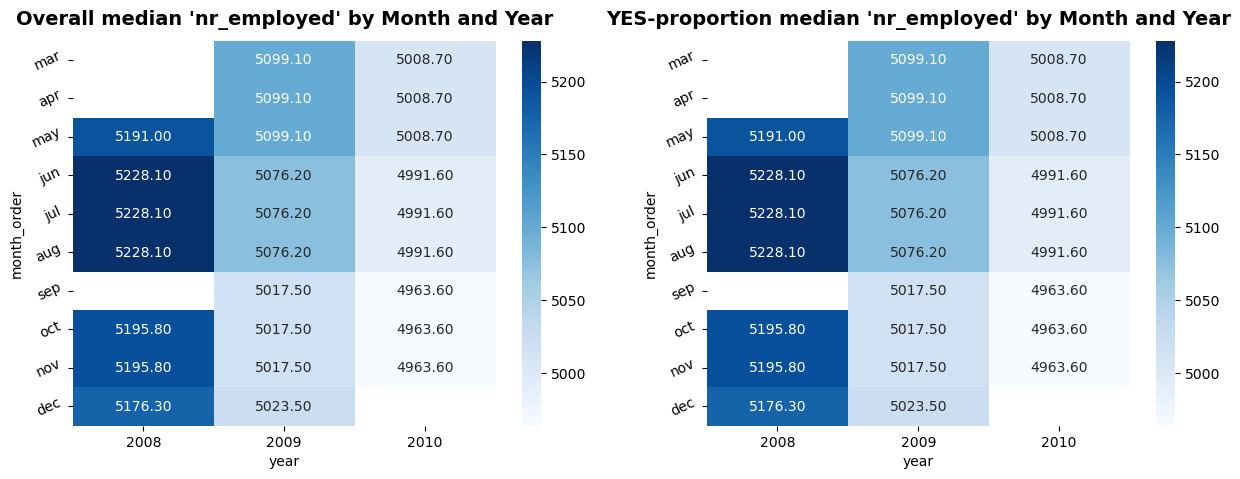

In [126]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'nr_employed', 'Month', fig=fig, ax=ax);

Median values of nr_employed by month and year for overall and yes-proportion data is same. These variables are good enough to differentiate nr_employed values for yes/no data.

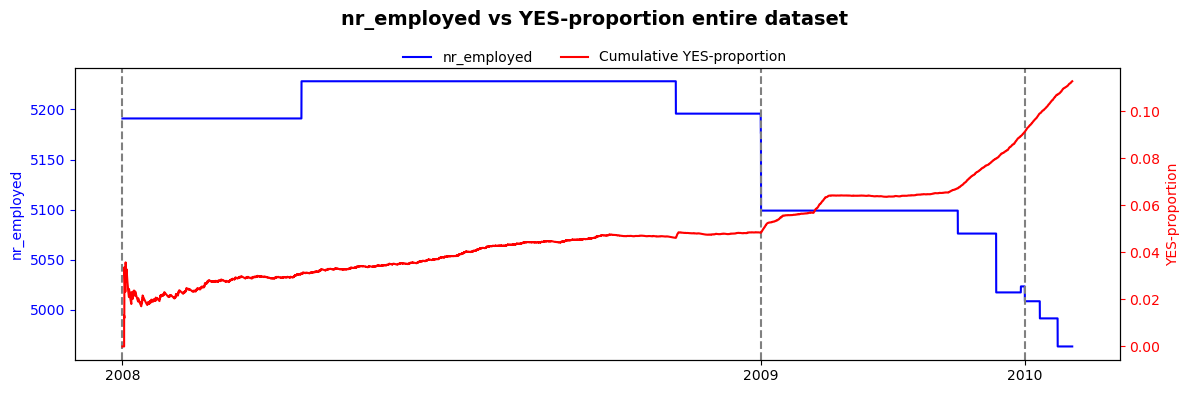

In [127]:
fig, ax = plt.subplots(figsize=(12, 4))
my_file.plot_num_var_yes_prop(tele_df, 'nr_employed', 'y_binary', fig=fig, ax=ax);


In [128]:
# Correlation with term deposit
feature_name = 'nr_employed'
print(f"Pearosn Correlation coeff (`{feature_name}` vs `y`) : {corr_df.loc[feature_name, 'y_binary']:.2f}")

Pearosn Correlation coeff (`nr_employed` vs `y`) : -0.35


There is negative correlation between nr.employed and y.

Check descriptive statistics distribution of Yes-No answers.

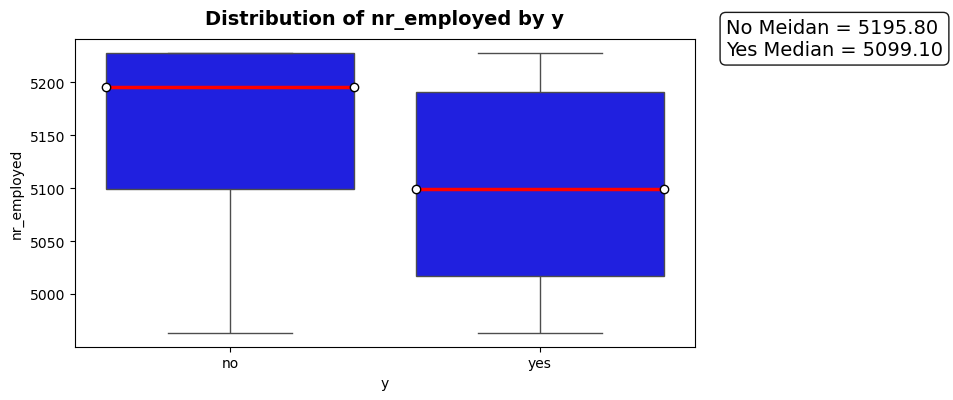

In [129]:
fig, ax = plt.subplots(figsize=(8, 4))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'nr_employed', fig=fig, ax=ax);


In [130]:
print("Various descriptive statistics of `nr_employed` by `y`\n")
print(tele_df.groupby(['y'])['nr_employed'].describe().round(2))

Various descriptive statistics of `nr_employed` by `y`

       count     mean    std     min     25%     50%     75%     max
y                                                                   
no   36548.0  5176.17  64.57  4963.6  5099.1  5195.8  5228.1  5228.1
yes   4640.0  5095.12  87.57  4963.6  5017.5  5099.1  5191.0  5228.1


We see the difference between medians, so this feature will be useful for classification.

In [132]:
# Compute variance in nr_employed by year
data = my_file.var_by_year(tele_df, 'year', 'nr_employed')
data['std'] = np.sqrt(data['variation of `nr_employed`']).round(2)
data['var_over_year'] = data['variation of `nr_employed`'].pct_change().round(2)

In 2009 the number of employed people was twice as high as in 2008 and 2010.

- 2008 & 2010: Employment was steady, so nr_employed adds little predictive power.
- 2009 : Employment fluctuated, making nr_employed more relevant for explaining changes in deposit subscription behavior.

In [133]:
print(f'Pearson corr. coef. (`{feature_name}` vs `emp_var_rate`): '
      f'{corr_df.loc[feature_name, 'emp_var_rate']:.2f}')

print(f'Pearson corr. coef. (`{feature_name}` vs `cons_price_idx`): '
      f'{corr_df.loc[feature_name, 'cons_price_idx']:.2f}')

print(f'Pearson corr. coef. (`{feature_name}` vs `cons_conf_idx`): '
      f'{corr_df.loc[feature_name, 'cons_conf_idx']:.2f}')

print(f'Pearson corr. coef. (`{feature_name}` vs `euribor3m`): '
      f'{corr_df.loc[feature_name, 'euribor3m']:.2f}')


Pearson corr. coef. (`nr_employed` vs `emp_var_rate`): 0.91
Pearson corr. coef. (`nr_employed` vs `cons_price_idx`): 0.52
Pearson corr. coef. (`nr_employed` vs `cons_conf_idx`): 0.10
Pearson corr. coef. (`nr_employed` vs `euribor3m`): 0.95


**Conclusion:**

- Values:
    - Number of unique values: 11
    - Vary from 4963.6 to 5228.1

- There is negative correlation (-0.35) between nr_employed and y.
- There is a huge difference between medians of nr_employed for YES/NO-answers.

---


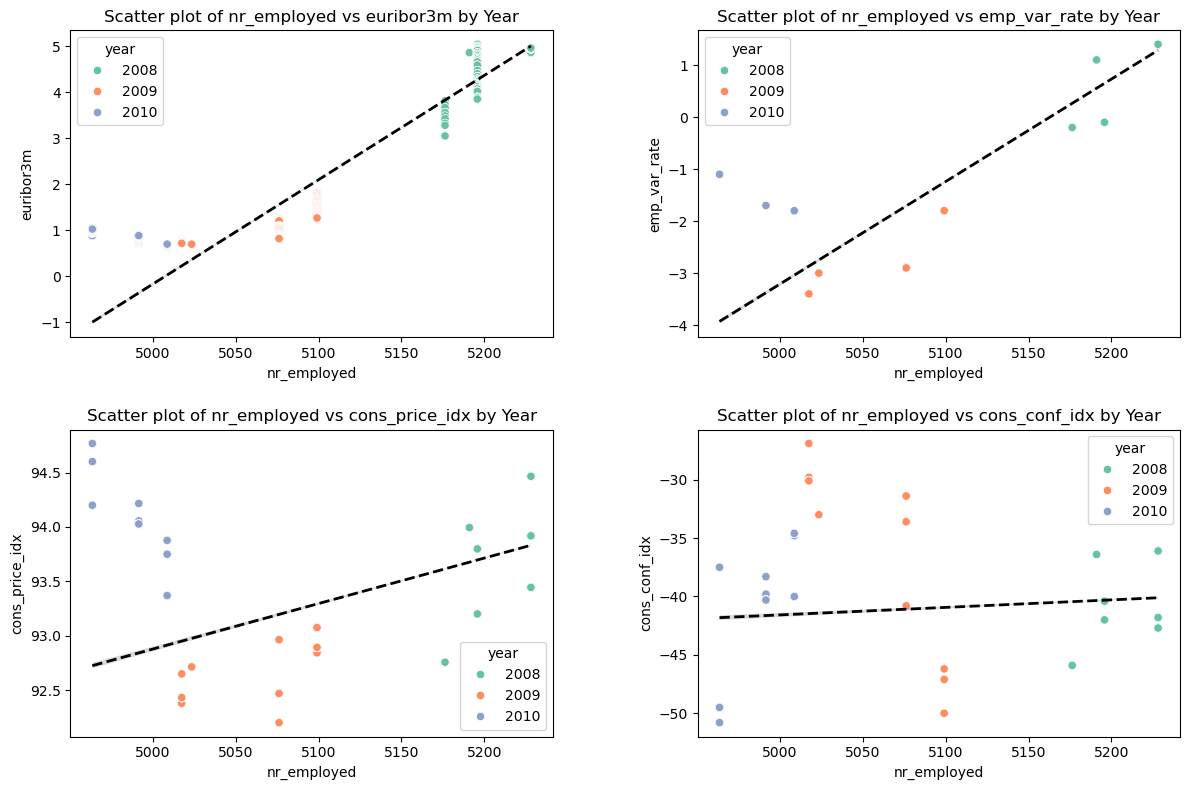

In [134]:
features = ['euribor3m', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx']

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for ax_, feature in zip(ax[:], features):
    sns.scatterplot(
        data=tele_df,
        x='nr_employed',
        y=feature,
        hue='year',
        palette='Set2',
        ax=ax_
    )
    ax_.set_title(f"Scatter plot of nr_employed vs {feature} by Year")
    # Add regression line (without hue, one line for all data) 
    sns.regplot( 
        data=tele_df, 
        x='nr_employed', y=feature, 
        scatter=False, ax=ax_, 
        color='black', 
        line_kws={'linewidth':2, 'linestyle':'--'} )
    #ax_.set_title(f"nr_employed vs {feature} by Year")

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Dimension : `y (term deposit)`**

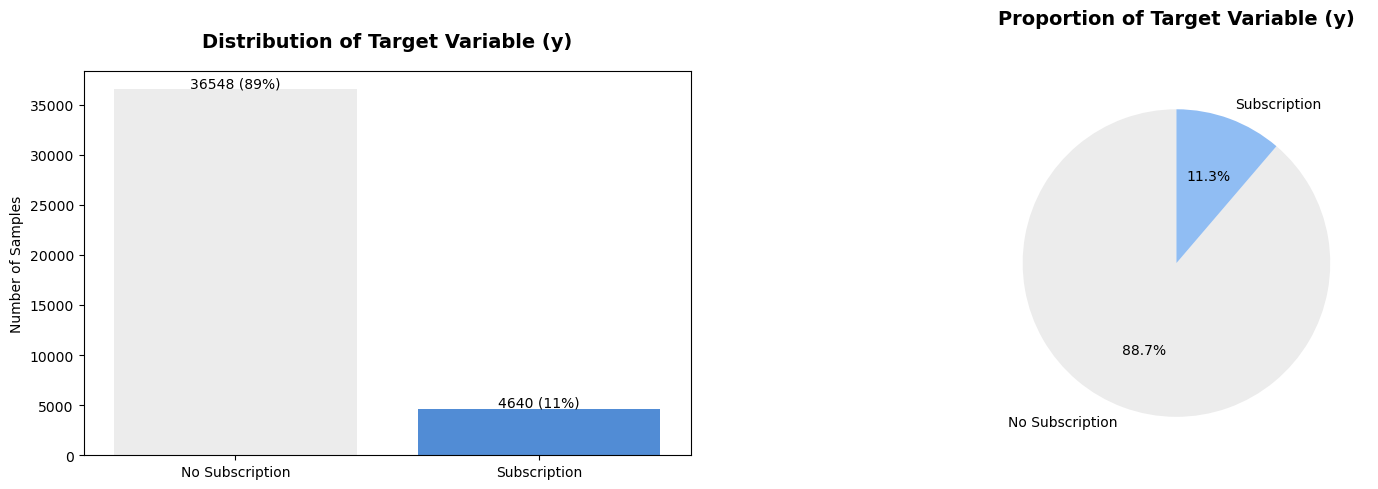

In [135]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

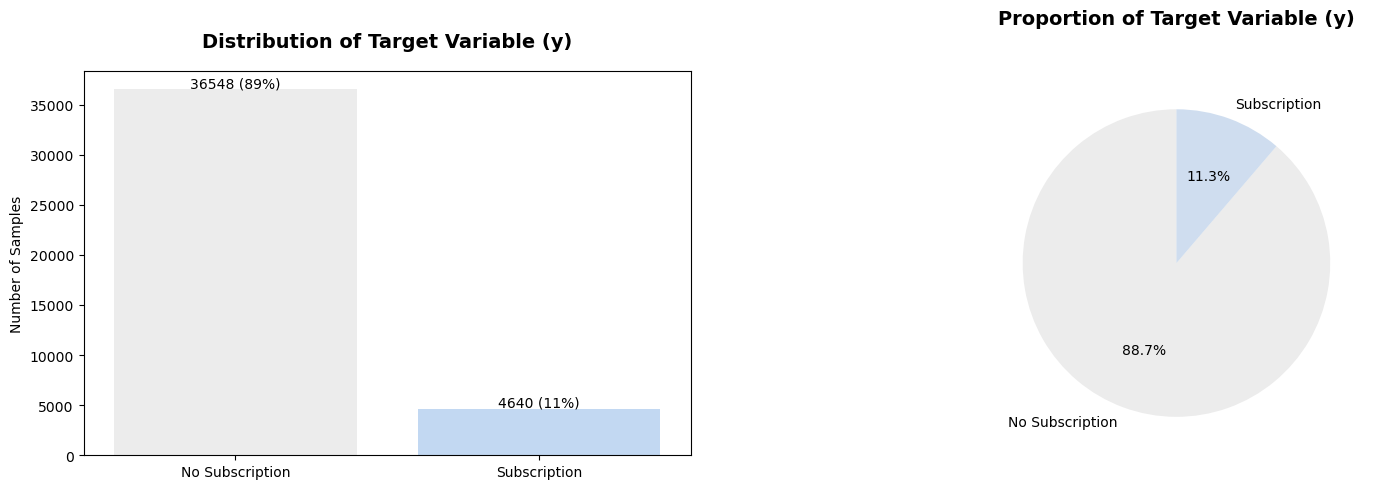

In [136]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', "#BAD7FAED"],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#AAC4E490"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

- **Highly imbalanced distribution overall**

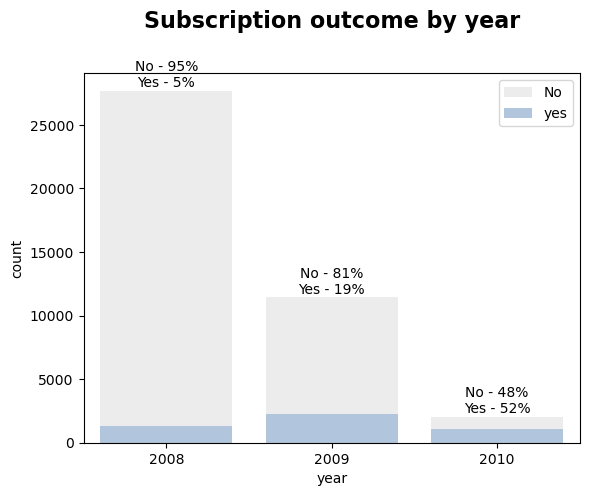

In [137]:
sns.countplot(tele_df, x='year', label='No', color='#ececec')
sns.countplot(tele_df[tele_df['y']=='yes'], x='year', label='yes', color='#AAC4E490')

# Compute relative percentages
text_val = tele_df.groupby(['year'])['y'].value_counts(normalize=True).unstack()*100
# Annotate text
for i, year in enumerate(text_val.index):
    no_pct = text_val.loc[year, 'no']
    yes_pct = text_val.loc[year, 'yes']
    label = f"No - {no_pct:.0f}%\nYes - {yes_pct:.0f}%"
    
    # Get the total height of the bar (No + Yes counts) 
    total_height = tele_df[tele_df['year'] == year].shape[0]
    
    # Place text slightly above the bar
    plt.text(i, total_height+50, label, ha='center', va='bottom', fontsize=10)
plt.title("Subscription outcome by year", fontsize=16, fontweight='bold', y=1.10);

- **A share of YES-answers was growing by year**

Let's look at the cumulative YES-proportion throghout the entire dataset:

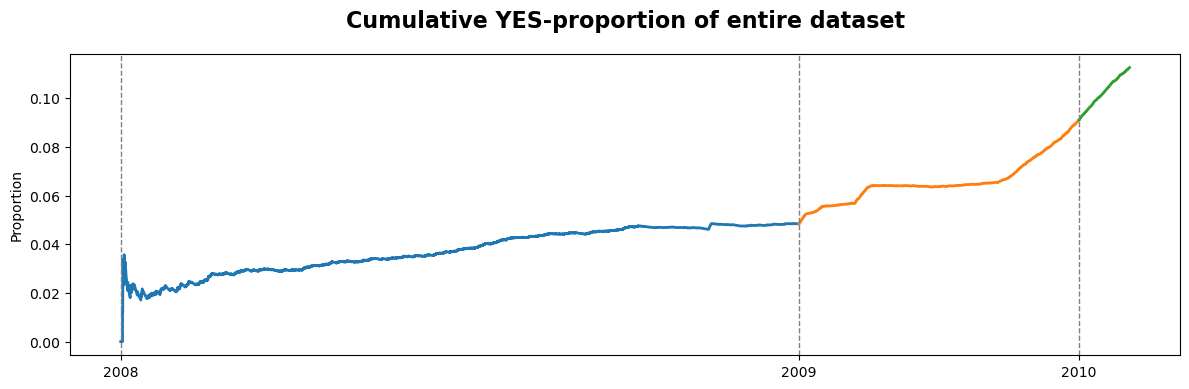

In [138]:
# Compute cumulative YES-proportion
cumulative_yes_proportion = np.cumsum(tele_df['y_binary']) / np.arange(1, tele_df.shape[0] + 1)
cumulative_yes_proportion = pd.Series(cumulative_yes_proportion)

# Visualization
fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(data = cumulative_yes_proportion[:27690], label=f"2008-yes", lw=2, ax=ax)
sns.lineplot(data = cumulative_yes_proportion[27690:39130], label=f"2009-yes", lw=2, ax=ax)
sns.lineplot(data = cumulative_yes_proportion[39130:], label=f"2010-yes", lw=2, ax=ax)

ax.set_ylabel('Proportion')
ax.set_title("Cumulative YES-proportion of entire dataset", fontsize=16, fontweight='bold', y=1.06)
# Mark years
year_indices = [0, 27690, 39130]
year_labels = [2008, 2009, 2010]
for idx in year_indices:
    ax.axvline(idx, lw=1, ls='--', c='grey')
ax.set_xticks(ticks=year_indices, labels=year_labels)

ax.get_legend().remove()
plt.tight_layout();

And now let's analyse the growth of YES-answers per year:

In [139]:
# Growth comparison (abs values)
print('=' * 50)
print('Growth comparison (absolute values: YES-proportion growth per year)')
print('=' * 50)
print(f'2008: '
      f'{cumulative_yes_proportion[:27690].max() - cumulative_yes_proportion[:27690].min():.3f}')
print(f'2009: '
      f'{cumulative_yes_proportion[27690:39130].max() - cumulative_yes_proportion[27690:39130].min():.3f}')
print(f'2010: '
      f'{cumulative_yes_proportion[39130:].max() - cumulative_yes_proportion[39130:].min():.3f}')


Growth comparison (absolute values: YES-proportion growth per year)
2008: 0.049
2009: 0.043
2010: 0.021


2008 was the best and 2009 is not to far from it, but this result is certainly affected by an uneven distribution of observations per year.

Then what about growth speed? That will give us much better values to compare. Let's check:

In [140]:
# Growth speed comparison (rel values)
growth_speed_2008 = (cumulative_yes_proportion[:27690].max() - 
                     cumulative_yes_proportion[:27690].min()) / 27690
growth_speed_2009 = (cumulative_yes_proportion[27690:39130].max() - 
                     cumulative_yes_proportion[27690:39130].min()) / (39130 - 27690)
growth_speed_2010 = (cumulative_yes_proportion[39130:].max() - 
                     cumulative_yes_proportion[39130:].min()) / (41188 - 39130)
print('=' * 50)
print('Growth speed comparison (relative values: YES-proportion growth per observation)')
print('=' * 50)
print(f'2008: {growth_speed_2008:.10f}')
print(f'2009: {growth_speed_2009:.10f}')
print(f'2010: {growth_speed_2010:.10f}')

Growth speed comparison (relative values: YES-proportion growth per observation)
2008: 0.0000017525
2009: 0.0000037391
2010: 0.0000104365


Now we see, that even though 2010 has the least growth, that growth was the fastest among all years.

**Conclusion :**

- Highly imbalanced distribution overall (89% of NO vs 11% of YES).
- A share of YES-answer was growing by year.
- 2008 has the highest, but, at the same time, the slowest growth of the YES-proportion.
- 2010 has the lowest, but, at the same time, the fastest growth of the YES-proportion.


In [141]:
print("=" * 60 + 'COMPLETED' + "="*60)

============================================================COMPLETED============================================================
